In [622]:
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier

In [623]:
def print_dir(obj):
    for i in dir(obj):
        if i.startswith("_"): continue
        print(i)

In [624]:
dataset = load_digits()
X = np.array(dataset["data"])
y = np.array(dataset["target"])
print(dataset.keys())
print(X.shape)
print(X.max())
print(X.std())
print(X[0])
print(y.max())
print(y.shape)

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 64)
16.0
6.016787548672236
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
9
(1797,)


In [625]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=.2)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1437, 64) (360, 64) (1437,) (360,)


In [626]:
results = []
def evaluate_classifier(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = (y_pred == y_test).mean()
    results.append({"name": name, "accuracy": acc})

    print(f"{name} accuracy: {acc:.4f}")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=dataset.target_names,
        cmap="Blues",
        values_format="d"
    )
    plt.title(f"{name} confusion matrix")
    plt.show()

    return y_pred

logistic_regression accuracy: 0.9722


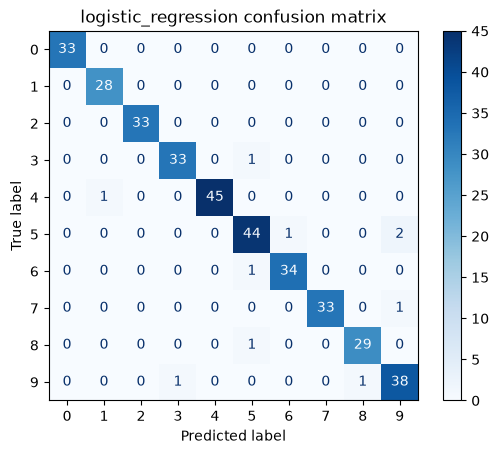

In [627]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=3000))
])

evaluate_classifier(model, "logistic_regression");

naive_bayes accuracy: 0.8472


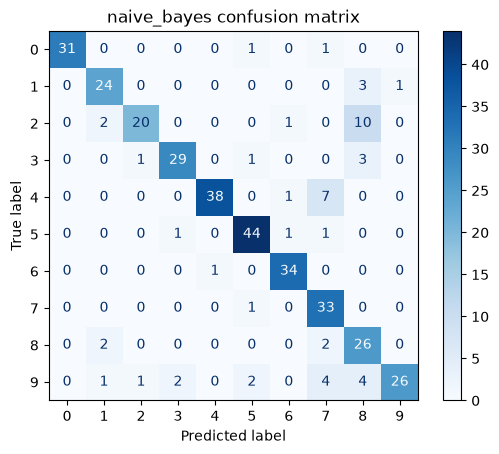

In [628]:
model = GaussianNB()
evaluate_classifier(model, "naive_bayes");

knn accuracy: 0.9750


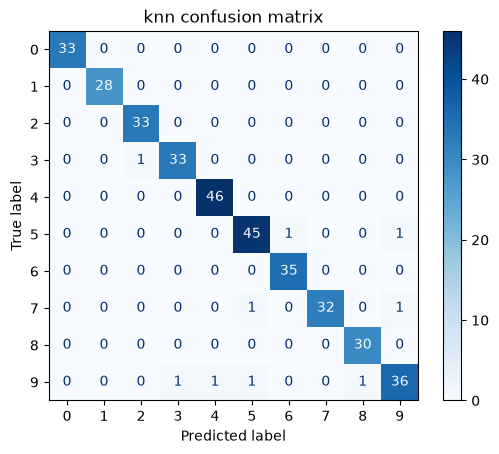

In [629]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])
evaluate_classifier(model, "knn");

decision_tree accuracy: 0.8500


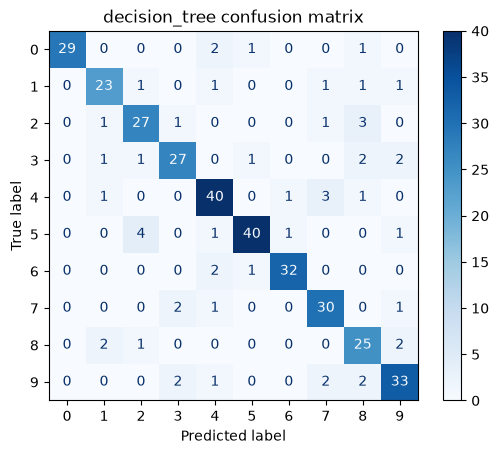

In [630]:
model = DecisionTreeClassifier(max_depth=8)
evaluate_classifier(model, "decision_tree");

svm accuracy: 0.9806


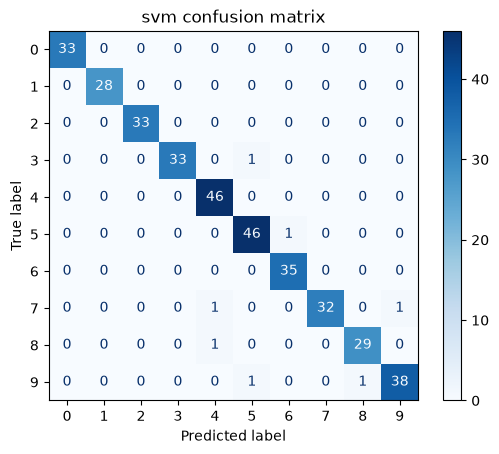

In [631]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC())
])
evaluate_classifier(model, "svm");

In [632]:
pd.DataFrame(results).sort_values("accuracy", ascending=False)

,name,accuracy
4,svm,0.980556
2,knn,0.975000
0,logistic_regression,0.972222
3,decision_tree,0.850000
1,naive_bayes,0.847222


In [633]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled= scaler.transform(X)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_test_pca = pca.transform(X_test_scaled)

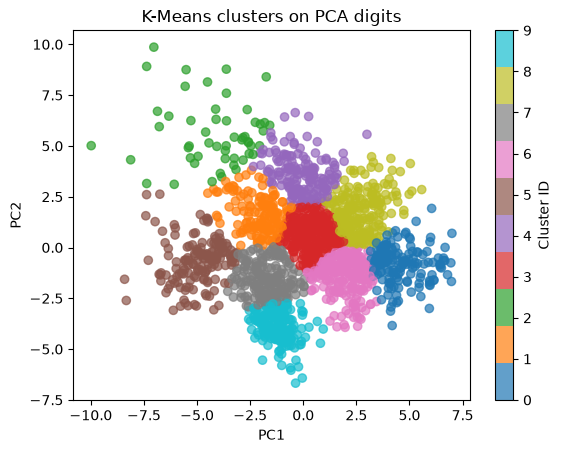

In [634]:
kmeans = KMeans(n_clusters=10, init="random", random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7)
plt.title("K-Means clusters on PCA digits")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()

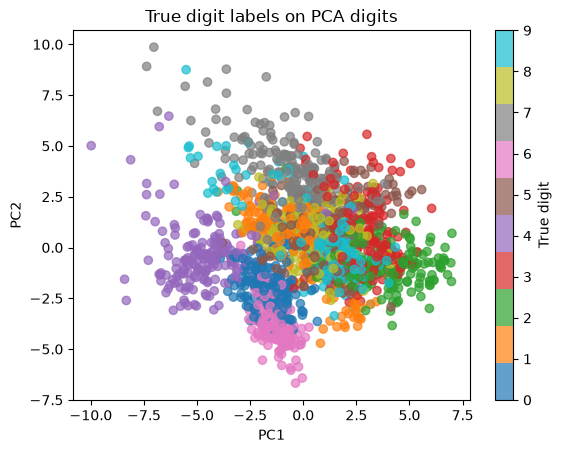

In [635]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", alpha=0.7)
plt.title("True digit labels on PCA digits")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="True digit")
plt.show()

acc: 0.54


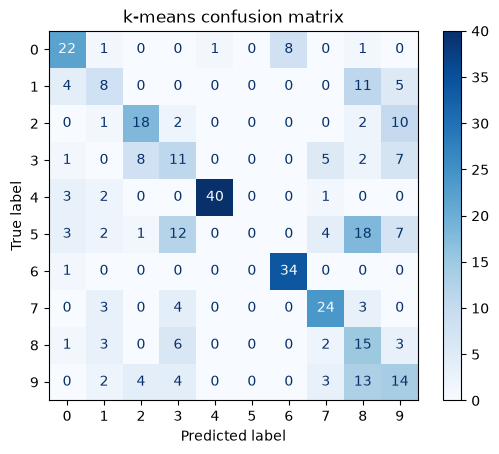

In [636]:
cluster_pred = kmeans.fit_predict(X_pca)
cluster_pred_test = kmeans.predict(X_test_pca)

from scipy.stats import mode

cluster_to_digit = {}

for cluster_id in np.unique(cluster_pred):
    mask = cluster_pred == cluster_id
    majority_digit = mode(y[mask], keepdims=False).mode
    cluster_to_digit[cluster_id] = majority_digit

digit_pred = np.array([cluster_to_digit[c] for c in cluster_pred])
digit_pred_test = np.array([cluster_to_digit[c] for c in cluster_pred_test])

test_acc = (digit_pred == y).mean()
print(f"acc: {test_acc:.2f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    digit_pred_test,
    display_labels=dataset.target_names,
    cmap="Blues",
    values_format="d"
)
plt.title(f"k-means confusion matrix")
plt.show()

In [637]:
for eps in [0.25, .3, .341, 0.5, 0.75, 1.0]:
    model = DBSCAN(eps=eps, min_samples=5)
    preds = model.fit_predict(X_pca)

    n_noise = (preds == -1).sum()
    n_clusters = len(set(preds)) - (1 if -1 in preds else 0)

    print("eps:", eps, "clusters:", n_clusters, "noise:", n_noise)

eps: 0.25 clusters: 35 noise: 452
eps: 0.3 clusters: 14 noise: 313
eps: 0.341 clusters: 10 noise: 236
eps: 0.5 clusters: 5 noise: 99
eps: 0.75 clusters: 2 noise: 33
eps: 1.0 clusters: 1 noise: 22


In [638]:
model = DBSCAN(eps=.341, min_samples=5)
preds = model.fit_predict(X_pca)
print_dir(model)

algorithm
components_
core_sample_indices_
eps
fit
fit_predict
get_metadata_routing
get_params
labels_
leaf_size
metric
metric_params
min_samples
n_features_in_
n_jobs
p
set_fit_request
set_params


clusters: 10
noise points: 236


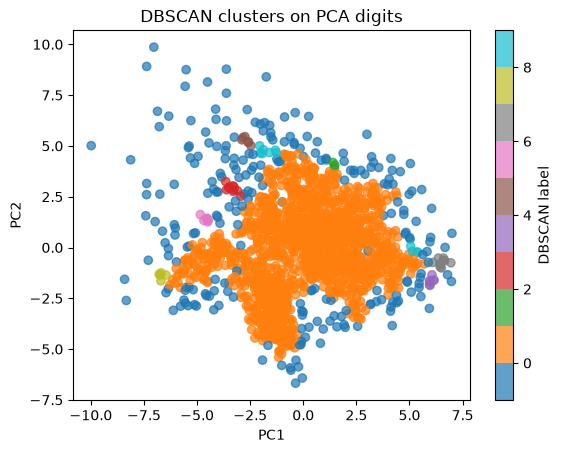

In [639]:
n_noise = (preds == -1).sum()
n_clusters = len(set(preds)) - (1 if -1 in preds else 0)

print("clusters:", n_clusters)
print("noise points:", n_noise)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=preds,
    cmap="tab10",
    alpha=0.7
)
plt.title("DBSCAN clusters on PCA digits")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="DBSCAN label")
plt.show()

In [640]:
ensemble_results = []
def ensemble_telemetry(model, name):
    t1 = perf_counter()
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    test_acc = (y_pred_test == y_test).mean()
    train_acc = (y_pred_train == y_train).mean()
    accuracy_gap = train_acc - test_acc
    dt = (perf_counter()-t1)
    ensemble_results.append({"name": name, "test_accuracy": test_acc, "train_accuracy": train_acc, "dt": dt, "accuracy_gap": accuracy_gap})

    print(f"{name}\ttest acc: {test_acc:.4f}\ttrain acc: {train_acc}\tdt: {dt:.2f}\taccuracy gap: {accuracy_gap:.2f}")
    return y_pred_test

In [641]:
shallow_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
deep_tree = DecisionTreeClassifier(random_state=42)
ensemble_telemetry(deep_tree, "deep-tree");
ensemble_telemetry(shallow_tree, "shallow-tree");

deep-tree	test acc: 0.8417	train acc: 1.0	dt: 0.02	accuracy gap: 0.16
shallow-tree	test acc: 0.6639	train acc: 0.6743215031315241	dt: 0.01	accuracy gap: 0.01


In [642]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42, n_jobs=-1)
ensemble_telemetry(model, "bagging");

bagging	test acc: 0.9417	train acc: 1.0	dt: 0.20	accuracy gap: 0.06


In [643]:
model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
ensemble_telemetry(model, "random-forest");

random-forest	test acc: 0.9750	train acc: 1.0	dt: 0.50	accuracy gap: 0.03


In [644]:
model = AdaBoostClassifier(random_state=42)
ensemble_telemetry(model, "ada-boost");

ada-boost	test acc: 0.7972	train acc: 0.7794015309672929	dt: 0.16	accuracy gap: -0.02


In [645]:
model = GradientBoostingClassifier(random_state=42)
ensemble_telemetry(model, "gradient-boosting");

gradient-boosting	test acc: 0.9694	train acc: 1.0	dt: 4.69	accuracy gap: 0.03


In [646]:
voting = VotingClassifier(
    estimators=[
        ("logreg", Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000))
        ])),
        ("knn", Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ])),
        ("svm", Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ])),
    ],
    voting="hard"
)

ensemble_telemetry(voting, "voting");

voting	test acc: 0.9778	train acc: 0.9972164231036882	dt: 0.25	accuracy gap: 0.02


In [647]:
pd.DataFrame(ensemble_results).sort_values("test_accuracy", ascending=False)

,name,test_accuracy,train_accuracy,dt,accuracy_gap
6,voting,0.977778,0.997216,0.247008,0.019439
3,random-forest,0.975000,1.000000,0.501861,0.025000
5,gradient-boosting,0.969444,1.000000,4.687462,0.030556
2,bagging,0.941667,1.000000,0.202057,0.058333
0,deep-tree,0.841667,1.000000,0.015498,0.158333
4,ada-boost,0.797222,0.779402,0.161072,-0.017821
1,shallow-tree,0.663889,0.674322,0.009091,0.010433


## CEOAI Section 2 Result: Finished For Sprint Use

This notebook now covers the practical CEOAI Section 2 workflow: classical supervised models, PCA, K-Means/DBSCAN clustering, and ensemble methods on one shared load_digits() setup.

Main result from the ensemble block:

| Model | Test accuracy | Train accuracy | Gap | Practical verdict |
| --- | ---: | ---: | ---: | --- |
| Voting | 0.9778 | 0.9972 | 0.0194 | Best score here, but not worth relying on under contest pressure. |
| Random Forest | 0.9750 | 1.0000 | 0.0250 | Best competition default: simple, strong, low-stress. |
| Gradient Boosting | 0.9694 | 1.0000 | 0.0306 | Strong, but slower and more validation-sensitive. |
| Bagging | 0.9417 | 1.0000 | 0.0583 | Proves averaging trees helps over one tree. |
| Deep Tree | 0.8417 | 1.0000 | 0.1583 | Memorizes; useful mainly as the reason ensembles exist. |
| AdaBoost | 0.7972 | 0.7794 | -0.0178 | Not useful on this setup. |

Conclusion: for competition use, I should reach first for a Random Forest after the basic classical baselines. Voting can be recognized as a committee method, but I do not need to depend on it in contest conditions.

CEOAI Section 2 status: finished enough for the sprint. Do not spend more time polishing this file unless a past task specifically forces hierarchical clustering or a submission-format benchmark. Move on.
